# 5. Diversity analysis


In this notebook we walk through the full diversity analysis for our dataset. We begin by checking sequencing depth with alpha rarefaction curves so we can choose a reasonable rarefaction level. We then run beta rarefaction to see how stable the beta diversity results are when we repeatedly subsample the data. Once we are confident about the depth, we calculate all core diversity metrics (both alpha and beta) at the chosen level.

After that, we use the standard QIIME2 visualizations to explore general patterns in the cohort. We then export the beta diversity distance matrices and move on to statistical testing. The built-in QIIME2 tests (PERMANOVA, ANOSIM, PERMDISP, Mantel) cannot take repeated measurements from the same infants into account, so we perform the PERMANOVA analysis in R instead. In R we try two ways of adjusting for repeated measurements: one where we include infant_id as a covariate, and one where we restrict permutations within each infant. These two approaches let us see which metadata variables can be properly tested when infants have multiple samples.

Finally, we create several visualizations of the ordinations. We look at the standard QIIME2 plots and also make our own custom PCoA figures, coloured by metadata and showing group centroids and confidence ellipses. These custom plots give us another view of how the metadata relates to beta diversity.

### Notebook Structure

**0.** Setup  

**1.** Rarefaction analyses  
&nbsp;&nbsp;&nbsp;&nbsp;**1.1** Alpha diversity rarefaction  
&nbsp;&nbsp;&nbsp;&nbsp;**1.2** Beta diversity rarefaction  

**2.** Diversity analysis (alpha & beta metrics)  
&nbsp;&nbsp;&nbsp;&nbsp;**2.1** Setting up filters and analysis parameters  
&nbsp;&nbsp;&nbsp;&nbsp;**2.2** Running QIIME2 core diversity metrics  
&nbsp;&nbsp;&nbsp;&nbsp;**2.3** Organizing and exporting diversity outputs  

**3.** Statistical analysis of beta diversity  
&nbsp;&nbsp;&nbsp;&nbsp;**3.1** Beta diversity statistical tests within QIIME2  
&nbsp;&nbsp;&nbsp;&nbsp;**3.2** Exporting beta diversity distance matrices for external testing  
&nbsp;&nbsp;&nbsp;&nbsp;**3.3** Running PERMANOVA using adonis2 in R  
&nbsp;&nbsp;&nbsp;&nbsp;**3.4** Summarizing and interpreting PERMANOVA results  
&nbsp;&nbsp;&nbsp;&nbsp;**3.5** Running PERMANOVA using adonis2 in R on individual age groups  

**4.** Visualization of diversity results  
&nbsp;&nbsp;&nbsp;&nbsp;**4.1** Standard QIIME2 diversity visualizations  
&nbsp;&nbsp;&nbsp;&nbsp;**4.2** Custom PCoA visualizations (centroids & ellipses) functions  
&nbsp;&nbsp;&nbsp;&nbsp;**4.3** Visualizing changing variables across measurement points  
&nbsp;&nbsp;&nbsp;&nbsp;**4.4** Visualizing static variables across measurement points  


<div style="border: 2px solid #1f77b4; padding: 10px; border-radius: 6px; background-color: #eaf3fb;">
    
<b> Research questions this notebook answers:</b>
- How does alpha diversity (e.g., richness, Shannon diversity) vary with age and across metadata groups such as feeding pattern, delivery mode, treatment, and geographic location?
- How does beta diversity (community composition differences) vary with age and between metadata groups, and which factors explain the largest share of variation?

</div>

## 0. Setup

In [1]:
# Import all necessary packages
import os
import glob
import shutil
from datetime import datetime
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import qiime2 as q2
from qiime2 import Artifact, Visualization
from skbio.stats.ordination import OrdinationResults
from ipywidgets import Dropdown, FloatSlider, Checkbox, VBox, HBox, IntSlider
import IPython
import re
%matplotlib inline

In [2]:
# Set working directory
# The working directory should normally default to the 'scripts' folder. 
# If it doesn't, set it manually using the command below.
# os.chdir("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts")  # Adjust this path to match your folder structure.

# Verify that your working directory is the 'scripts' folder inside the main project directory (.../MicrobiomeAnalysis_TummyTribe/scripts)
cwd = os.getcwd()
if not cwd.endswith("MicrobiomeAnalysis_TummyTribe/scripts"):
    print("WARNING: The working directory is not set to the 'scripts' folder inside 'MicrobiomeAnalysis_TummyTribe'!")
    print("Current working directory:", cwd)
    print("Please set it manually using os.chdir().")
else:
    print(f"Working directory is correctly set to the 'scripts' folder (\"{cwd}\").")

Working directory is correctly set to the 'scripts' folder ("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts").


In [3]:
# Data directories
raw_data_dir = "../data/raw"
meta_data_dir = "../data/processed/metadata"
denoising_data_dir = "../data/processed/denoising"
taxonomy_data_dir = "../data/processed/taxonomy"
phylogeny_data_dir = "../data/processed/phylogeny"
diversity_data_dir = "../data/processed/diversity"
# Create the new diversity analysis folder

In [4]:
%%bash -s "$diversity_data_dir"
mkdir -p "$1"

### Set run and metric to work with

This section creates a small set of interactive widgets that allow us to adjust rarefaction depth and apply optional metadata filters before running the diversity analyses. These widgets make the pipeline more flexible, but we also set the default values to match the parameters used in the main project results. This means that if you simply run the notebook without changing anything, you will reproduce the same results we obtained during the original analysis. The rarefaction depth slider lets us choose how many sequencing reads to subsample per sample. The default depth of 14,000 was selected because it retained most samples while providing enough reads to capture community structure reliably. The minimum and maximum bounds (5,000–20,000) allow for quick testing and sensitivity checks if needed.

In addition to rarefaction, we include optional metadata filters. These allow us to restrict the dataset by age, country, or milk type, depending on the comparison you want to explore. The filter toggle determines whether these filters are applied. The dropdown menus use only the metadata values that appeared frequently in the dataset or that were part of the main comparisons in the project:

- Age: 4, 7, or 10 months (the main sampling ages)

- Country: Russia, Estonia or Finland

- Milk type: “bd” (breast-derived) or “fd” (formula-derived)

By default, all filters are turned off so the full dataset is included, matching the pipeline used for the project’s primary results. These widgets simply provide a convenient, interactive way to rerun the analysis with different subsets of the data if you want to explore alternative comparisons or replicate sensitivity checks.

In [5]:
# Rarefaction depth options
depth_selector = IntSlider(
    value=14000,          # default
    min=5000,
    max=20000,
    step=1000,            # change in increments of 1000
    description="Depth:",
    continuous_update=False
)

# Switch sample filtering on/off
filter_toggle = Checkbox(
    value=False,
    description="Enable filtering"
)

# Age filter: only three possible values
age_selector = Dropdown(
    options=[None, 4.0, 7.0, 10.0],
    value=None,
    description="Age (months):"
)

# Country filter
country_selector = Dropdown(
    options=[None, "Russia", "Finland"],
    value=None,
    description="Country:"
)

# Milk type filter
milk_selector = Dropdown(
    options=[None, "bd", "fd"],
    value=None,
    description="Milk type:"
)

VBox([
    depth_selector,
    filter_toggle,
    age_selector,
    country_selector,
    milk_selector
])

In [6]:
# Read values from the filtering + depth widgets
sampling_depth = depth_selector.value
enable_sample_filtering = filter_toggle.value
filter_age_months = age_selector.value
filter_country = country_selector.value
filter_milk_type = milk_selector.value

print("Running core microbiota pipeline with:")
print(sampling_depth, enable_sample_filtering, filter_age_months, filter_country, filter_milk_type)

Running core microbiota pipeline with:
14000 False None None None


## 1. Rarefaction Analyses

Rarefaction analyses help us check whether our sequencing depth is high enough to reliably capture microbial diversity. We perform both alpha and beta rarefaction to see how within-sample diversity and between-sample differences change as sequencing depth increases.

### 1.1 Alpha rarefaction  

First, we perform alpha rarefaction to examine how sequencing depth affects within-sample diversity and to help choose an appropriate rarefaction depth for later analyses. The minimum and maximum rarefaction depths are based on the sequencing depth distribution observed in the feature table.

In [7]:
! qiime feature-table summarize \
    --i-table $taxonomy_data_dir/dada2_table_filtered.qza \
    --m-sample-metadata-file $meta_data_dir/metadata_merged.tsv \
    --o-visualization $taxonomy_data_dir/dada2_table_filtered.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/taxonomy/dada2_table_filtered.qzv


In [8]:
Visualization.load(f"{taxonomy_data_dir}/dada2_table_filtered.qzv")

<visualization: Visualization uuid: 807cf9d1-defc-46a2-a37f-27f9a73a2263>

We set the minimum sampling depth to 1 as a reference point, even though depths below approximately 5,000 reads are not biologically meaningful for this dataset. Based on the sequencing depth distribution in the feature table, we chose a maximum depth of 55,000 reads, which retains at least three-quarters of the samples. A step size of 15 was used to create a smooth range of rarefaction depths.

In [9]:
! qiime diversity alpha-rarefaction \
    --i-table $taxonomy_data_dir/dada2_table_filtered.qza \
    --p-max-depth 55000 \
    --p-steps 15 \
    --m-metadata-file $meta_data_dir/metadata_merged.tsv \
    --o-visualization $diversity_data_dir/alpha-rarefaction.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/diversity/alpha-rarefaction.qzv


In [10]:
Visualization.load(f"{diversity_data_dir}/alpha-rarefaction.qzv")

<visualization: Visualization uuid: 3a28ebd0-2e44-4a92-a391-e0315f4f138d>

### 1.2 Beta Rarefaction 

Next, we perform beta rarefaction to check how stable between-sample diversity patterns are when the data are repeatedly subsampled. By rarefying the data multiple times and recalculating Bray-Curtis distances, we can see whether the overall clustering is consistent or sensitive to sequencing depth. For this analysis, we use a sampling depth of 14,000 reads, which was selected based on the sequencing depth distribution and the alpha rarefaction results, and retains most samples while providing sufficient coverage.

In [11]:
! qiime diversity beta-rarefaction \
  --i-table $taxonomy_data_dir/dada2_table_filtered.qza \
  --p-metric braycurtis \
  --p-clustering-method upgma \
  --m-metadata-file $meta_data_dir/metadata_merged.tsv \
  --p-sampling-depth {sampling_depth} \
  --p-iterations 10 \
  --o-visualization $diversity_data_dir/beta-rarefaction-braycurtis.qzv \
  --verbose

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/conda/lib/python3.10/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:146: RuntimeWarning: The result contains negative eigenvalues. Please compare their magnitude with the magnitude of some of the largest positive eigenvalues. If the negative ones are smaller, it's probably safe to ignore them, but if they are large in magnitude, the results won't be useful. See the Notes section for more details. The smallest eigenvalue is -0.4161727776535876 and the largest is 12.48466403781836.
  warn(
/opt/conda/lib/python3.10/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:146: RuntimeWarning: The result contains negative eig

In [12]:
Visualization.load(f"{diversity_data_dir}/beta-rarefaction-braycurtis.qzv")

<visualization: Visualization uuid: a0c99f2c-e473-4d0a-9908-38f297aba4ea>

## 2. Diversity analysis (alpha & beta metrics)  

In this section, we calculate alpha and beta diversity metrics using a fixed rarefaction depth. These analyses quantify within-sample diversity and between-sample community differences and form the basis for the statistical testing and visualizations that follow.


### 2.1 Setting up filters and analysis parameters

These are the settings used for this diversity analysis. Here we define the rarefaction depth and optional filtering choices. Changing these values will affect the downstream core-metrics results.

In [13]:
# Input files
table_raw = f"{taxonomy_data_dir}/dada2_table_filtered.qza"
tree_qza  = f"{phylogeny_data_dir}/sepp-tree.qza"
metadata  = f"{meta_data_dir}/metadata_merged.tsv"

Based on the filtering settings above, we create a short label and a folder where all outputs from this run will be stored. This helps to keep different runs organized.

In [14]:
# Build a short label describing the filtering settings

filter_label_parts = []

if enable_sample_filtering:
    if filter_age_months:
        filter_label_parts.append(f"age-{filter_age_months}")
    if filter_country:
        filter_label_parts.append(f"country-{filter_country}")
    if filter_milk_type:
        filter_label_parts.append(f"milk-{filter_milk_type}")

# If nothing was added, mark it as "no-filter"
filter_label = "_".join(filter_label_parts) if filter_label_parts else "no-filter"

# Directory for storing all results of this run
run_dir = f"{diversity_data_dir}/depth-{sampling_depth}_{filter_label}"

!mkdir {run_dir}
print("Run directory:", run_dir)

Run directory: ../data/processed/diversity/depth-14000_no-filter


If filtering is turned on, samples are selected using metadata conditions (age, country, or milk type). Otherwise, we use the full table. The filtered or unfiltered table is then passed to the main diversity pipeline.

In [15]:
# Apply sample filtering based on metadata (if activated)

if enable_sample_filtering:
    print("Filtering enabled...")

    filtered_table = f"{run_dir}/filtered_table.qza"
    where_conditions = []

    # Add conditions depending on what the user set
    if filter_age_months is not None:
        where_conditions.append(f"age_months = {filter_age_months}")
    if filter_country is not None:
        where_conditions.append(f"geo_location_name = '{filter_country}'")
    if filter_milk_type is not None:
        where_conditions.append(f"diet_milk = '{filter_milk_type}'")

    # Combine everything into a single WHERE statement
    where_sql = " AND ".join(where_conditions)
    print("WHERE:", where_sql)

    # Run QIIME2 filtering
    !qiime feature-table filter-samples \
        --i-table {table_raw} \
        --m-metadata-file {metadata} \
        --p-where "{where_sql}" \
        --o-filtered-table {filtered_table}

    table_for_run = filtered_table

else:
    print("No filtering applied.")
    table_for_run = table_raw

No filtering applied.


### 2.2 Running QIIME2 core diversity metrics  

In this step we run QIIME2’s core-metrics-phylogenetic pipeline.
This calculates all standard diversity metrics (alpha and beta) at the chosen rarefaction depth [[QIIME 2 Documentation, 2024](https://docs.qiime2.org/2024.10/plugins/available/diversity/core-metrics-phylogenetic/)].
The results are stored inside the run directory so we can generate visualizations later.

In [16]:
print("Running core metrics...")

!qiime diversity core-metrics-phylogenetic \
  --i-table {table_for_run} \
  --i-phylogeny {tree_qza} \
  --m-metadata-file {metadata} \
  --p-sampling-depth {sampling_depth} \
  --output-dir {run_dir}/core_metrics

Running core metrics...
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/diversity/depth-14000_no-filter/core_metrics/rarefied_table.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/diversity/depth-14000_no-filter/core_metrics/faith_pd_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/diversity/depth-14000_no-filter/core_metrics/observed_features_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/diversity/depth-14000_no-filter/core_metrics/shannon_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/diversity/depth-14000_no-filter/core_metrics/evenness_vector.qza
Saved DistanceMatrix to: ../data/processed/d

This part of the pipeline generates visual summaries of alpha diversity (within-sample diversity) and beta diversity (between-sample differences). It takes the outputs from QIIME2’s core metrics analysis and turns them into interpretable .qzv visualization files that can be viewed in QIIME2 View.

In [17]:
# This cell takes quite some time, time to enjoy a coffee!

print("Generating alpha & beta visualizations...")

# Alpha diversity visualizations
# Loop through alpha diversity vectors and create significance visualizations
alpha_vis_commands = [
    ("faith_pd_vector.qza",           "faith-pd-group-significance.qzv"),
    ("shannon_vector.qza",            "shannon-group-significance.qzv"),
    ("observed_features_vector.qza",  "observed-features-group-significance.qzv"),
    ("evenness_vector.qza",           "evenness-group-significance.qzv")
]

for infile, outfile in alpha_vis_commands:
    input_path = f"{run_dir}/core_metrics/{infile}"       # input alpha diversity vector
    output_path = f"{run_dir}/core_metrics/{outfile}"     # output .qzv file
    
    if os.path.exists(input_path):                        # only run if file exists
        !qiime diversity alpha-group-significance \
            --i-alpha-diversity {input_path} \
            --m-metadata-file {metadata} \
            --o-visualization {output_path}

print("Finished alpha visualizations!")


# Beta diversity emperor plots
# Create 3D PCoA emperor plots for each beta diversity metric
beta_vis_commands = [
    ("unweighted_unifrac_pcoa_results.qza", "unweighted_unifrac_emperor.qzv"),
    ("weighted_unifrac_pcoa_results.qza",   "weighted_unifrac_emperor.qzv"),
    ("jaccard_pcoa_results.qza",            "jaccard_emperor.qzv"),
    ("bray_curtis_pcoa_results.qza",        "bray_curtis_emperor.qzv")
]

for pcoa_file, vis_file in beta_vis_commands:
    pcoa_path = f"{run_dir}/core_metrics/{pcoa_file}"     # input PCoA results
    output_path = f"{run_dir}/core_metrics/{vis_file}"    # output emperor plot
    
    if os.path.exists(pcoa_path):                         # check PCoA exists
        !qiime emperor plot \
            --i-pcoa {pcoa_path} \
            --m-metadata-file {metadata} \
            --o-visualization {output_path}

print("Finished beta visualizations!")

Generating alpha & beta visualizations...
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/diversity/depth-14000_no-filter/core_metrics/faith-pd-group-significance.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/diversity/depth-14000_no-filter/core_metrics/shannon-group-significance.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: Us

### 2.3 Organizing and exporting diversity outputs  


Running the core metrics pipeline generates a very large number of files, especially once all alpha diversity metrics, beta diversity matrices, PCoA results, visualizations, and statistical test outputs are produced. If everything remains inside the core_metrics folder, it quickly becomes difficult to navigate and keep track of which files belong to which part of the analysis.

To maintain a clean and well-structured working directory, we sort the outputs into separate folders for alpha and beta diversity. This organizational step does not change any of the results; it simply improves clarity and makes it much easier to locate specific artifacts or visualizations later in the workflow. 

In [18]:
# Create folders for storing metrics and visualizations

alpha_metrics_dir = f"{run_dir}/alpha/metrics"
alpha_vis_dir     = f"{run_dir}/alpha/visualizations"
beta_metrics_dir  = f"{run_dir}/beta/metrics"
beta_vis_dir      = f"{run_dir}/beta/visualizations"
beta_stats_dir = f"{run_dir}/beta/statistical_tests"

# Make the directories if they don't already exist
for d in [alpha_metrics_dir, alpha_vis_dir, beta_metrics_dir, beta_vis_dir, beta_stats_dir]:
    os.makedirs(d, exist_ok=True)

Now we move the alpha diversity results (both the numeric vectors and the QZV visualizations) into the corresponding folders.

In [19]:
# Move alpha diversity artifacts (metrics)
alpha_files = [
    "faith_pd_vector.qza",
    "shannon_vector.qza",
    "observed_features_vector.qza",
    "evenness_vector.qza"
]

for fname in alpha_files:
    src = f"{run_dir}/core_metrics/{fname}"
    if os.path.exists(src):
        shutil.move(src, f"{alpha_metrics_dir}/{fname}")

# Move alpha diversity visualizations
for _, vis_name in alpha_vis_commands:
    src = f"{run_dir}/core_metrics/{vis_name}"
    if os.path.exists(src):
        shutil.move(src, f"{alpha_vis_dir}/{vis_name}")

We do the same for beta diversity: distance matrices, PCoA results, and their emperor plots.

In [20]:
# Move beta diversity artifacts (distance matrices + PCoA files + statistical tests)
beta_files = [
    "unweighted_unifrac_distance_matrix.qza",
    "unweighted_unifrac_pcoa_results.qza",
    "weighted_unifrac_distance_matrix.qza",
    "weighted_unifrac_pcoa_results.qza",
    "bray_curtis_distance_matrix.qza",
    "bray_curtis_pcoa_results.qza",
    "jaccard_distance_matrix.qza",
    "jaccard_pcoa_results.qza"
]

for fname in beta_files:
    src = f"{run_dir}/core_metrics/{fname}"
    if os.path.exists(src):
        shutil.move(src, f"{beta_metrics_dir}/{fname}")

# Move beta emperor visualizations
for _, vis_name in beta_vis_commands:
    src = f"{run_dir}/core_metrics/{vis_name}"
    if os.path.exists(src):
        shutil.move(src, f"{beta_vis_dir}/{vis_name}")
        
# Move statistical tests

# Move all PERMANOVA, ANOSIM, PERMDISP, and Mantel test files
patterns = [
    f"{run_dir}/core_metrics/*permanova_*.qzv",
    f"{run_dir}/core_metrics/*anosim_*.qzv",
    f"{run_dir}/core_metrics/*permdisp_*.qzv",
    f"{run_dir}/core_metrics/mantel_*.qzv"
]

for pattern in patterns:
    for src in glob.glob(pattern):
        fname = os.path.basename(src)
        shutil.move(src, f"{beta_stats_dir}/{fname}")

The rarefied feature table is still needed for downstream analyses, so we keep it in the main run directory. After reorganizing the outputs, we remove the remaining core_metrics folder to reduce clutter if it is empty, or rename it if any files remain for reference.


In [21]:
# Move rarefied table to the run directory (keep this file)
rarefied_table = f"{run_dir}/core_metrics/rarefied_table.qza"
if os.path.exists(rarefied_table):
    shutil.move(rarefied_table, run_dir)

alpha_rarefaction = f"{diversity_data_dir}/alpha-rarefaction.qzv"
if os.path.exists(alpha_rarefaction):
    shutil.move(alpha_rarefaction, run_dir)   
    
core_dir = f"{run_dir}/core_metrics"

# If empty: remove folder
if os.path.exists(core_dir) and len(os.listdir(core_dir)) == 0:
    shutil.rmtree(core_dir)
else:
    # If not empty: rename to avoid deleting leftover files
    new_name = f"{core_dir}_leftover"
    if os.path.exists(core_dir):
        os.rename(core_dir, new_name)

## 3. Statistical analysis of beta diversity 

In this notebook, we perform statistical analyses only for beta diversity. We do not perform statistical testing for alpha diversity in this notebook, because the dataset contains repeated measurements from the same infants. Alpha diversity will be analyzed in the next notebook using linear mixed-effects models, which are appropriate for assessing statistical significance in paired alpha diversity data.

For beta diversity, we first explored several statistical tests available in QIIME 2, including PERMANOVA, ANOSIM, PERMDISP, and Mantel tests. These tests treat all samples as independent and do not allow us to restrict permutations or include a subject identifier. Because each infant was sampled multiple times, this assumption is violated, and these tests are not appropriate for our dataset. The code for these analyses is kept in this notebook for reference, but the results are not used for interpretation.

For the final beta diversity analysis, we use PERMANOVA implemented with the adonis2 function in R [[Oksanen et al., 2025](https://search.r-project.org/CRAN/refmans/vegan/html/adonis.html)]
. This method allows us to include host_id as a covariate, which helps account for repeated measurements from the same infant. This approach improves our ability to distinguish true group-level differences from variation between individual infants.

### 3.1 Beta diversity statistical tests within QIIME2  

In the next cell, you can see the QIIME 2 beta diversity statistical tests that were initially explored, including PERMANOVA, ANOSIM, PERMDISP, and Mantel tests across multiple distance metrics and metadata variables. This cell is commented out and shown only for reference.

Because these QIIME 2 tests cannot account for repeated measurements from the same infant, they are not appropriate for our longitudinal dataset. As a result, the outputs from this cell are not used for interpretation in the final analysis.



In [22]:
# This cell also takes quite some time, time to enjoy another coffee (at least 30 minutes)!

# # Metadata columns to test
# group_columns = ["geo_location_name", "delivery_mode", "diet_milk", "treatment_exposure", "age_months", "diet_weaning"]

# print("Running beta-group significance tests for selected metadata columns...")

# # Beta-group significance analyses (PERMANOVA, ANOSIM, PERMDISP)
# # These tests check whether groups differ in community composition
# beta_distance_matrices = [
#     ("unweighted_unifrac_distance_matrix.qza", "unweighted_unifrac"),
#     ("weighted_unifrac_distance_matrix.qza",   "weighted_unifrac"),
#     ("jaccard_distance_matrix.qza",            "jaccard"),
#     ("bray_curtis_distance_matrix.qza",        "bray_curtis")
# ]

# for dm_file, prefix in beta_distance_matrices:
#     dm_path = f"{run_dir}/beta/metrics/{dm_file}"   # distance matrix
    
#     if os.path.exists(dm_path):

#         for group_column in group_columns:          # loop through the selected metadata columns

#             # PERMANOVA (default)
#             !qiime diversity beta-group-significance \
#                 --i-distance-matrix {dm_path} \
#                 --m-metadata-file {metadata} \
#                 --m-metadata-column {group_column} \
#                 --o-visualization {run_dir}/core_metrics/{prefix}_permanova_{group_column}.qzv \
#                 --p-permutations 999

#             # ANOSIM
#             !qiime diversity beta-group-significance \
#                 --i-distance-matrix {dm_path} \
#                 --m-metadata-file {metadata} \
#                 --m-metadata-column {group_column} \
#                 --o-visualization {run_dir}/core_metrics/{prefix}_anosim_{group_column}.qzv \
#                 --p-method anosim \
#                 --p-permutations 999

#             # PERMDISP
#             !qiime diversity beta-group-significance \
#                 --i-distance-matrix {dm_path} \
#                 --m-metadata-file {metadata} \
#                 --m-metadata-column {group_column} \
#                 --o-visualization {run_dir}/core_metrics/{prefix}_permdisp_{group_column}.qzv \
#                 --p-method permdisp \
#                 --p-permutations 999

# print("Finished beta-group significance tests!")

# # Mantel tests 
# dm_paths = {
#     name: f"{run_dir}/core_metrics/{file}"
#     for file, name in [
#         ("unweighted_unifrac_distance_matrix.qza", "unweighted"),
#         ("weighted_unifrac_distance_matrix.qza",   "weighted"),
#         ("jaccard_distance_matrix.qza",            "jaccard"),
#         ("bray_curtis_distance_matrix.qza",        "bray")
#     ]
# }

# for (name1, path1), (name2, path2) in itertools.combinations(dm_paths.items(), 2):
#     if os.path.exists(path1) and os.path.exists(path2):   # ensure both matrices exist
#         output_path = f"{run_dir}/core_metrics/mantel_{name1}_vs_{name2}.qzv"
        
#         !qiime diversity mantel \
#             --i-dm1 {path1} \
#             --i-dm2 {path2} \
#             --o-visualization {output_path} \
#             --p-permutations 999

# print("Finished Mantel tests!")

### 3.2 Exporting beta diversity distance matrices for external testing

In the next cell, we export the QZA distance matrix files so they can be used outside of QIIME 2. Each QZA file is converted into a folder containing a distance-matrix.tsv file, which is required as input for the PERMANOVA analysis in R and allows more flexible statistical modeling than is possible within QIIME 2.

In [23]:
beta_distance_matrices = [
    ("unweighted_unifrac_distance_matrix.qza", "unweighted_unifrac_export"),
    ("weighted_unifrac_distance_matrix.qza",   "weighted_unifrac_export"),
    ("jaccard_distance_matrix.qza",            "jaccard_export"),
    ("bray_curtis_distance_matrix.qza",        "bray_curtis_export")
]

print("Exporting QIIME2 distance matrices to TSV...\n")

for qza_name, tsv_name in beta_distance_matrices:
    
    print(f"  Converting {qza_name}  →  {tsv_name}")
    
    # Export feature importance from the raw feature-volatility output
    !qiime tools export \
      --input-path {beta_metrics_dir}/{qza_name} \
      --output-path {beta_metrics_dir}/{tsv_name}

print("\nFinished exporting all distance matrices!")

Exporting QIIME2 distance matrices to TSV...

  Converting unweighted_unifrac_distance_matrix.qza  →  unweighted_unifrac_export
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/diversity/depth-14000_no-filter/beta/metrics/unweighted_unifrac_distance_matrix.qza as DistanceMatrixDirectoryFormat to directory ../data/processed/diversity/depth-14000_no-filter/beta/metrics/unweighted_unifrac_export
  Converting weighted_unifrac_distance_matrix.qza  →  weighted_unifrac_export
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for remo

### 3.3 Running PERMANOVA using adonis2 in R  

Before running PERMANOVA in R, we need to configure the R environment inside Jupyter. In this step, we install the required R packages, enable R support in the notebook, and pass key file paths from Python to R so they can be accessed in later analyses.


In [24]:
# Install required R packages only if they are not already installed
# These packages are needed to run PERMANOVA (adonis2) in R

required_packages = ["r-base", "r-vegan", "r-permute", "rpy2"]

# Get a list of installed conda packages
installed_packages = !conda list
installed_packages = "\n".join(installed_packages)

# Check which required packages are missing
missing_packages = [
    pkg for pkg in required_packages if pkg not in installed_packages
]

# Install only the missing packages
if len(missing_packages) > 0:
    print("Installing missing R packages:", missing_packages)
    !conda install -c conda-forge {" ".join(missing_packages)} -y
else:
    print("All required R packages are already installed.")

All required R packages are already installed.


In [25]:
# Enable R support inside the Jupyter notebook
# This allows us to run R code using the %%R magic
%load_ext rpy2.ipython

# Pass important paths from Python to the R environment
# RUN_DIR points to the main analysis directory
# METADATA points to the sample metadata file
os.environ["RUN_DIR"] = run_dir
os.environ["METADATA"] = metadata

# Print the variables to confirm they are set correctly
print("RUN_DIR:", os.environ["RUN_DIR"])
print("METADATA:", os.environ["METADATA"])

RUN_DIR: ../data/processed/diversity/depth-14000_no-filter
METADATA: ../data/processed/metadata/metadata_merged.tsv


In this step, we run PERMANOVA (adonis2) [[Oksanen et al., 2025](https://search.r-project.org/CRAN/refmans/vegan/html/adonis.html)]
for each beta diversity metric and for each metadata variable separately. This produces one PERMANOVA result per variable per distance metric, which we later summarize and compare.

Because the dataset contains repeated measurements from the same infant, we explicitly account for host identity in the analysis. The pipeline supports two approaches. In the first approach, permutations are restricted within each host_id, which preserves the repeated-measures structure during randomization. In the second approach, host_id is included as a covariate in the PERMANOVA model, allowing us to estimate the effect of each metadata variable while adjusting for differences between infants.

Only one mode is selected at a time. For the main pipeline, we keep the analysis fixed to the permutation-based approach, because it directly preserves the longitudinal structure of the data during resampling and avoids treating host identity as a fixed explanatory variable. This makes the test more conservative and better aligned with the repeated-measures design of the study.


In [26]:
%%R
library(vegan)

# choose one of the modes here
mode <- "restricted"   # Options: "restricted" (permutation-based) or "covariate"

run_adonis2 <- function(dm, meta, group_col,
                        mode = c("restricted", "covariate"),
                        host_col = "host_id",
                        permutations = 999,
                        by = "margin") {

    # Choose between the two supported options
    mode <- match.arg(mode)

    # Check that columns exist
    if (!group_col %in% colnames(meta)) {
        stop(paste("Column", group_col, "not found in metadata."))
    }
    if (!host_col %in% colnames(meta)) {
        stop(paste("Host ID column", host_col, "not found in metadata."))
    }

    ###############################################################
    # OPTION 1 — Restricted permutations
    #
    # Model:    dm ~ group_col
    # Permute:  within each host
    #
    # Interpretation:
    # - The model tests the effect of group_col.
    # - Permutations are kept within host_id groups, which means
    #   samples from different hosts are not intermixed during resampling.
    ###############################################################
    if (mode == "restricted") {

        formula_str <- paste("dm ~", group_col)
        fm <- as.formula(formula_str)

        res <- adonis2(
            fm,
            data = meta,
            permutations = permutations,
            by = by,
            strata = meta[[host_col]]   # apply within-host permutations
        )

        attr(res, "mode") <- "restricted"
    }

    ###############################################################
    # OPTION 2 — Host ID as a covariate
    #
    # Model:    dm ~ group_col + host_id
    # Permute:  across all samples
    #
    # Interpretation:
    # - Host ID is included as an explanatory variable in the model.
    # - Useful when you want to understand variation attributed to
    #   your variable of interest after adjusting for host differences.
    # - Permutations are not restricted here.
    ###############################################################
    if (mode == "covariate") {

        formula_str <- paste("dm ~", group_col, "+", host_col)
        fm <- as.formula(formula_str)

        res <- adonis2(
            fm,
            data = meta,
            permutations = permutations,
            by = by
        )

        attr(res, "mode") <- "covariate"
    }

    return(res)
}

# Metadata variables to test
group_columns <- c("geo_location_name", "delivery_mode",
                   "diet_milk", "treatment_exposure",
                   "age_months", "diet_weaning")

# Distance metric folders
beta_distance_folders <- list(
    unweighted_unifrac = "unweighted_unifrac_export",
    weighted_unifrac   = "weighted_unifrac_export",
    jaccard            = "jaccard_export",
    bray_curtis        = "bray_curtis_export"
)

# Paths passed from Python
metadata_path <- Sys.getenv("METADATA")
run_dir       <- Sys.getenv("RUN_DIR")

if (metadata_path == "" || run_dir == "") {
    stop("ERROR: METADATA or RUN_DIR were not set from Python.")
}

# Load metadata
meta <- read.table(metadata_path, sep="\t", header=TRUE, row.names=1)

if (!("host_id" %in% colnames(meta))) {
    stop("ERROR: metadata must contain a 'host_id' column.")
}

# Create output folder
output_dir <- file.path(run_dir, "beta", "metrics", paste0("adonis2_mode_", mode))
dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)

cat("\n=============================================\n")
cat(" Running PERMANOVA\n")
cat(" Mode:", mode, "\n")
cat(" Saving results to:", output_dir, "\n")
cat("=============================================\n\n")


# MAIN LOOP OVER ALL DISTANCE MATRICES
for (prefix in names(beta_distance_folders)) {

    cat("Processing metric:", prefix, "\n")

    folder_path <- file.path(run_dir, "beta", "metrics", beta_distance_folders[[prefix]])
    dm_file <- file.path(folder_path, "distance-matrix.tsv")

    if (!file.exists(dm_file)) {
        cat("  Skipped: no distance matrix found.\n\n")
        next
    }

    # Load distance matrix
    dm_df <- read.table(dm_file, sep="\t", header=TRUE, row.names=1, check.names=FALSE)

    # Ensure sample IDs match metadata
    common_ids <- intersect(rownames(dm_df), rownames(meta))

    if (length(common_ids) < 3) {
        cat("  Skipped: too few overlapping samples.\n\n")
        next
    }

    # Subset both matrices
    dm <- as.dist(as.matrix(dm_df[common_ids, common_ids]))
    meta_sub <- meta[common_ids, ]


    # LOOP OVER EACH METADATA VARIABLE
    for (group_col in group_columns) {

        if (!group_col %in% colnames(meta_sub)) {
            cat("  Skipping variable:", group_col, "(not in metadata)\n")
            next
        }

        # Run PERMANOVA using the chosen mode
        res <- run_adonis2(
            dm       = dm,
            meta     = meta_sub,
            group_col = group_col,
            mode      = mode,
            host_col  = "host_id",
            permutations = 999
        )

        # Output filename
        out_file <- file.path(
            output_dir,
            paste0(prefix, "_adonis2_", mode, "_", group_col, ".tsv")
        )

        write.table(
            as.data.frame(res),
            file = out_file,
            sep = "\t", quote = FALSE,
            col.names = NA
        )

        cat("  Saved:", out_file, "\n")
    }

    cat("\n")
}

# save the mode that we used for use in file path in the next python code cell
Sys.setenv(PERMANOVA_MODE = mode)

cat("Completed PERMANOVA in mode:", mode, "\n")

R[write to console]: Loading required package: permute

R[write to console]: Loading required package: lattice

R[write to console]: This is vegan 2.6-8




 Running PERMANOVA
 Mode: restricted 
 Saving results to: ../data/processed/diversity/depth-14000_no-filter/beta/metrics/adonis2_mode_restricted 

Processing metric: unweighted_unifrac 
  Saved: ../data/processed/diversity/depth-14000_no-filter/beta/metrics/adonis2_mode_restricted/unweighted_unifrac_adonis2_restricted_geo_location_name.tsv 
  Saved: ../data/processed/diversity/depth-14000_no-filter/beta/metrics/adonis2_mode_restricted/unweighted_unifrac_adonis2_restricted_delivery_mode.tsv 
  Saved: ../data/processed/diversity/depth-14000_no-filter/beta/metrics/adonis2_mode_restricted/unweighted_unifrac_adonis2_restricted_diet_milk.tsv 
  Saved: ../data/processed/diversity/depth-14000_no-filter/beta/metrics/adonis2_mode_restricted/unweighted_unifrac_adonis2_restricted_treatment_exposure.tsv 
  Saved: ../data/processed/diversity/depth-14000_no-filter/beta/metrics/adonis2_mode_restricted/unweighted_unifrac_adonis2_restricted_age_months.tsv 
  Saved: ../data/processed/diversity/depth-140

### 3.4 Summarizing and interpreting PERMANOVA results 

Each PERMANOVA test produces a separate TSV file, with one file per metadata variable and distance metric. To make the results easier to compare and interpret, we collect all of these files and merge them into a single summary table in the next cell.


In [27]:
# Read all PERMANOVA result files produced by adonis2
# Each file corresponds to one metadata variable and one distance metric

mode = os.getenv("PERMANOVA_MODE", "restricted")
print("Using PERMANOVA mode:", mode)

results_dir = f"{run_dir}/beta/metrics/adonis2_mode_{mode}"
print("Results directory:", results_dir)

rows = []

# Loop over all result files in the output directory
for file in os.listdir(results_dir):
    if file.endswith(".tsv"):

        # Extract distance metric and metadata variable from the filename
        m = re.match(rf"(.*?)_adonis2_{mode}_(.*?)\.tsv$", file)
        if not m:
            continue

        dist_metric = m.group(1)
        meta_var = m.group(2)

        # Load the PERMANOVA results table
        df = pd.read_csv(os.path.join(results_dir, file), sep="\t", index_col=0)

        # Skip files where the expected metadata variable is not present
        if meta_var not in df.index:
            continue

        # Extract statistics for the metadata variable of interest
        stats = df.loc[meta_var]

        # Store relevant values in a list of rows
        rows.append({
            "metadata_variable": meta_var,
            "metric": dist_metric,
            "F_value": stats["F"],
            "R2": stats["R2"],
            "p_value": stats["Pr(>F)"],
        })

# Combine all collected rows into a single dataframe
summary = pd.DataFrame(rows)


# Convert metadata variable names into more readable labels
summary["metadata_variable"] = (
    summary["metadata_variable"]
    .str.replace("_", " ")
    .str.title()
    .str.replace("Geo Location Name", "Geo Location")
)

# Replace raw distance metric names with nicer labels
metric_rename = {
    "weighted_unifrac": "Weighted UniFrac",
    "unweighted_unifrac": "Unweighted UniFrac",
    "bray_curtis": "Bray-Curtis",
    "jaccard": "Jaccard"
}
summary["metric"] = summary["metric"].replace(metric_rename)

# Add significance stars based on p-values
def stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

summary["sig"] = summary["p_value"].apply(stars)

# Round numeric values for cleaner presentation
summary["F_value"] = summary["F_value"].round(3)
summary["R2"] = summary["R2"].round(4)
summary["p_value"] = summary["p_value"].round(3)

# Define a logical order for metadata variables
sort_order = [
    "Age Months",
    "Diet Milk",
    "Diet Weaning",
    "Delivery Mode",
    "Geo Location",
    "Treatment Exposure"
]
summary["metadata_variable"] = pd.Categorical(
    summary["metadata_variable"],
    categories=sort_order,
    ordered=True
)

# Sort the final summary table
summary_global = summary.sort_values(["metadata_variable", "metric"])

# Display the summarized PERMANOVA results
print("Final summarized PERMANOVA results:")
summary_global

Using PERMANOVA mode: restricted
Results directory: ../data/processed/diversity/depth-14000_no-filter/beta/metrics/adonis2_mode_restricted
Final summarized PERMANOVA results:


,metadata_variable,metric,F_value,R2,p_value,sig
12,Age Months,Bray-Curtis,5.179,0.0165,0.001,**
18,Age Months,Jaccard,6.245,0.0199,0.001,**
23,Age Months,Unweighted UniFrac,15.645,0.0483,0.001,**
13,Age Months,Weighted UniFrac,12.137,0.0379,0.001,**
0,Diet Milk,Bray-Curtis,2.647,0.0253,0.001,**
9,Diet Milk,Jaccard,2.188,0.0210,0.001,**
2,Diet Milk,Unweighted UniFrac,3.533,0.0335,0.001,**
22,Diet Milk,Weighted UniFrac,5.974,0.0553,0.002,**
7,Diet Weaning,Bray-Curtis,2.446,0.0157,0.001,**
19,Diet Weaning,Jaccard,2.040,0.0131,0.001,**


The summarized PERMANOVA results in the table show two clear patterns that depend on whether a metadata variable changes within infants over time.

Variables that change within infants, such as Age Months, Diet Milk, and Diet Weaning, show consistent and statistically significant effects across all beta diversity metrics. In the table, these variables have p-values of 0.001 or 0.010 and are marked with significance stars for Bray–Curtis, Jaccard, and both UniFrac distances. Age Months shows the strongest and most consistent effects, with relatively high F values and R² values across all metrics, indicating that age explains a meaningful proportion of variation in community structure. Diet Milk and Diet Weaning also show significant but smaller effect sizes, suggesting more moderate changes in beta diversity as feeding patterns evolve over time.

In contrast, variables that remain constant within each infant, including Delivery Mode, Geo Location, and Treatment Exposure, consistently return p-values of 1.0 across all distance metrics in the table. This pattern is observed even when F values and R² values appear non-zero, such as for Geo Location with weighted UniFrac or Delivery Mode with weighted UniFrac. These results indicate that, despite apparent between-infant differences, PERMANOVA cannot test these variables in a repeated-measures setting because they do not vary within infants.

This contrast is visible directly in the table: all time-varying variables show significant p-values across metrics, while all time-invariant variables show p-values of 1.0. Both the covariate-based and restricted permutation approaches lead to the same interpretation. PERMANOVA can reliably evaluate variables with within-infant variation, but it cannot meaningfully test variables that are constant within individuals in a longitudinal design.

Because several important predictors in this study, such as Delivery Mode, Geo Location, and Treatment Exposure, do not change within infants, we take an additional approach to evaluate their effects. To remain consistent in the statistical framework, we continue to use PERMANOVA with adonis2, but we run the analysis separately for each age group and include only one sample per infant. This avoids the issue of repeated measurements while allowing us to test these time-invariant variables. This analysis is performed in the next section (3.5).

### 3.5 Running PERMANOVA using adonis2 in R on individual age groups

In this section, we test metadata variables that do not change within infants, such as delivery mode, geographic location, and treatment exposure. To avoid issues with repeated measurements, we run PERMANOVA separately for each age group and include only one sample per infant at a time. By analyzing each age group independently and removing duplicate samples per host, we can use adonis2 while maintaining a valid statistical design. This allows us to evaluate time-invariant variables in a way that is consistent with the beta diversity analyses performed earlier.

In [28]:
# Pass paths to the R environment for the age-stratified PERMANOVA analysis
os.environ["RUN_DIR"] = run_dir
os.environ["METADATA"] = metadata

# Confirm that the variables are set correctly
print("RUN_DIR:", os.environ["RUN_DIR"])
print("METADATA:", os.environ["METADATA"])

RUN_DIR: ../data/processed/diversity/depth-14000_no-filter
METADATA: ../data/processed/metadata/metadata_merged.tsv


The following code implements this age-stratified PERMANOVA approach. For each beta diversity metric, the analysis is run separately at each age, after selecting a single sample per infant and matching the metadata to the corresponding distance matrix. The results are saved for later inspection and comparison.


In [29]:
%%R

# Clear the R environment to avoid conflicts from previous cells
rm(list = ls())

library(vegan)

# Metadata variables that do not change within infants
static_vars <- c(
    "geo_location_name",
    "delivery_mode",
    "treatment_exposure"
)

# Age groups to analyze separately
ages <- c(4, 7, 10)

# Location of exported distance matrices
beta_distance_folders <- list(
    unweighted_unifrac = "unweighted_unifrac_export",
    weighted_unifrac   = "weighted_unifrac_export",
    jaccard            = "jaccard_export",
    bray_curtis        = "bray_curtis_export"
)

# Paths passed from Python
metadata_path <- Sys.getenv("METADATA")
run_dir       <- Sys.getenv("RUN_DIR")

if (metadata_path == "" || run_dir == "") {
    stop("ERROR: METADATA or RUN_DIR not set from Python.")
}

# Load metadata
meta <- read.table(metadata_path, sep = "\t", header = TRUE, row.names = 1)

if (!("host_id" %in% colnames(meta))) {
    stop("ERROR: metadata must contain a 'host_id' column.")
}

# Output directory for age-stratified PERMANOVA results
static_dir <- file.path(run_dir, "beta", "metrics", "adonis2_static_vars")
dir.create(static_dir, recursive = TRUE, showWarnings = FALSE)

cat("Running PERMANOVA for static variables by age group\n\n")

# Loop over beta diversity distance metrics
for (prefix in names(beta_distance_folders)) {

    cat("Processing metric:", prefix, "\n")

    dm_path <- file.path(
        run_dir,
        "beta", "metrics",
        beta_distance_folders[[prefix]],
        "distance-matrix.tsv"
    )

    if (!file.exists(dm_path)) {
        cat("  Distance matrix not found, skipping\n\n")
        next
    }

    # Load distance matrix
    dm_df <- read.table(
        dm_path, sep = "\t", header = TRUE,
        row.names = 1, check.names = FALSE
    )
    dm <- as.matrix(dm_df)

    # Loop over age groups
    for (age in ages) {

        cat("  Age:", age, "months\n")

        # Subset metadata to one age group
        meta_age <- subset(meta, age_months == age)

        # Keep only one sample per infant
        meta_age <- meta_age[!duplicated(meta_age[, c("host_id", "age_months")]), ]

        # Match samples between metadata and distance matrix
        ids <- intersect(rownames(meta_age), rownames(dm))

        if (length(ids) < 3) {
            cat("    Too few samples after filtering, skipping\n")
            next
        }

        meta_age <- meta_age[ids, ]
        dm_sub <- as.dist(dm[ids, ids])

        # Loop over static metadata variables
        for (var in static_vars) {

            if (!(var %in% colnames(meta_age))) {
                cat("    Variable not found:", var, "\n")
                next
            }

            # Skip variables with no group variation
            if (length(unique(meta_age[[var]])) < 2) {
                cat("    Only one group for", var, ", skipping\n")
                next
            }

            # Construct PERMANOVA formula
            formula <- as.formula(paste("dm_sub ~", var))

            # Run PERMANOVA
            res <- adonis2(formula, data = meta_age)

            # Save result
            out_file <- file.path(
                static_dir,
                paste0(prefix, "_age", age, "_", var, "_adonis2.tsv")
            )

            write.table(
                as.data.frame(res),
                out_file,
                sep = "\t", quote = FALSE,
                col.names = NA
            )

            cat("    Saved:", out_file, "\n")
        }
    }

    cat("\n")
}

cat("Completed age-stratified PERMANOVA analysis\n")

Running PERMANOVA for static variables by age group

Processing metric: unweighted_unifrac 
  Age: 4 months
    Saved: ../data/processed/diversity/depth-14000_no-filter/beta/metrics/adonis2_static_vars/unweighted_unifrac_age4_geo_location_name_adonis2.tsv 
    Saved: ../data/processed/diversity/depth-14000_no-filter/beta/metrics/adonis2_static_vars/unweighted_unifrac_age4_delivery_mode_adonis2.tsv 
    Saved: ../data/processed/diversity/depth-14000_no-filter/beta/metrics/adonis2_static_vars/unweighted_unifrac_age4_treatment_exposure_adonis2.tsv 
  Age: 7 months
    Saved: ../data/processed/diversity/depth-14000_no-filter/beta/metrics/adonis2_static_vars/unweighted_unifrac_age7_geo_location_name_adonis2.tsv 
    Saved: ../data/processed/diversity/depth-14000_no-filter/beta/metrics/adonis2_static_vars/unweighted_unifrac_age7_delivery_mode_adonis2.tsv 
    Saved: ../data/processed/diversity/depth-14000_no-filter/beta/metrics/adonis2_static_vars/unweighted_unifrac_age7_treatment_exposure_a

In this step, we collect the PERMANOVA results generated for the age-stratified analyses of static metadata variables. All result files are parsed and combined into a single summary table, which allows us to compare effects across age groups, distance metrics, and metadata variables.


In [30]:
# Read PERMANOVA result files for static variables
# Each file corresponds to one distance metric, one age group, and one metadata variable

results_dir = f"{run_dir}/beta/metrics/adonis2_static_vars"
print("Reading PERMANOVA files from:", results_dir)

rows = []

# Filename pattern:
# <metric>_age<age>_<metadata_variable>_adonis2.tsv
pattern = r"^(.*?)_age(\d+)_(.*?)_adonis2\.tsv$"

for file in os.listdir(results_dir):
    if not file.endswith(".tsv"):
        continue

    match = re.match(pattern, file)
    if not match:
        continue

    # Extract information from the filename
    dist_metric = match.group(1)
    age = int(match.group(2))
    meta_var = match.group(3)

    # Load the PERMANOVA result table
    df = pd.read_csv(os.path.join(results_dir, file), sep="\t", index_col=0)

    # Always use the "Model" row, which contains the overall test result
    if "Model" not in df.index:
        print(f"File {file} does not contain a 'Model' row, skipping.")
        continue

    stats = df.loc["Model"]

    # Store the relevant statistics
    rows.append({
        "Age": age,
        "metadata_variable": meta_var,
        "metric": dist_metric,
        "F_value": stats["F"],
        "R2": stats["R2"],
        "p_value": stats["Pr(>F)"],
    })

# Combine all parsed results into a single dataframe
summary = pd.DataFrame(rows)

if summary.empty:
    raise ValueError("No PERMANOVA results were parsed. Check file names and structure.")

# Convert metadata variable names into more readable labels
summary["metadata_variable"] = (
    summary["metadata_variable"]
    .str.replace("_", " ")
    .str.title()
    .str.replace("Geo Location Name", "Geo Location")
)

# Replace raw distance metric names with nicer labels
metric_rename = {
    "weighted_unifrac": "Weighted UniFrac",
    "unweighted_unifrac": "Unweighted UniFrac",
    "bray_curtis": "Bray-Curtis",
    "jaccard": "Jaccard"
}
summary["metric"] = summary["metric"].replace(metric_rename)

# Add significance stars based on p-values
def stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

summary["sig"] = summary["p_value"].apply(stars)

# Round numeric values for cleaner display
summary["F_value"] = summary["F_value"].round(3)
summary["R2"] = summary["R2"].round(4)
summary["p_value"] = summary["p_value"].round(3)

# Sort the table by metadata variable, age, and distance metric
summary_static = summary.sort_values(
    ["metadata_variable", "Age", "metric"]
)

# Display the final summary table
print("Final summarized static-variable PERMANOVA results:")
summary_static

Reading PERMANOVA files from: ../data/processed/diversity/depth-14000_no-filter/beta/metrics/adonis2_static_vars
Final summarized static-variable PERMANOVA results:


,Age,metadata_variable,metric,F_value,R2,p_value,sig
5,4,Delivery Mode,Bray-Curtis,1.645,0.0184,0.043,*
31,4,Delivery Mode,Jaccard,1.119,0.0126,0.136,
17,4,Delivery Mode,Unweighted UniFrac,1.709,0.0191,0.017,*
8,4,Delivery Mode,Weighted UniFrac,4.138,0.0449,0.006,**
9,7,Delivery Mode,Bray-Curtis,1.038,0.0106,0.374,
18,7,Delivery Mode,Jaccard,1.073,0.0109,0.210,
30,7,Delivery Mode,Unweighted UniFrac,0.987,0.0101,0.458,
27,7,Delivery Mode,Weighted UniFrac,2.761,0.0277,0.026,*
35,10,Delivery Mode,Bray-Curtis,1.048,0.0096,0.367,
11,10,Delivery Mode,Jaccard,0.982,0.0090,0.528,


The age-stratified PERMANOVA results show that the effects of static metadata variables vary across age groups and beta diversity metrics.

Geo Location shows the strongest and most consistent association with beta diversity across all ages. At 4, 7, and 10 months, Geo Location is significant for all distance metrics, with relatively high F values and R² values, especially for weighted UniFrac. This indicates stable and substantial differences in community composition between geographic locations at all sampled ages.

Delivery Mode shows weaker and less consistent effects. At 4 months, several metrics, including Bray–Curtis and both UniFrac distances, show significant or near-significant associations, while at 7 and 10 months most metrics are not significant. Weighted UniFrac remains significant at all ages, suggesting that delivery mode may influence phylogenetically weighted community structure, but the overall effect size is small.

Treatment Exposure shows modest and age-dependent effects. At 4 months, most metrics are not significant, with the exception of weighted UniFrac. At 7 and 10 months, significance appears for some metrics, but the effects are weaker and less consistent than those observed for Geo Location. This suggests that treatment exposure may have a subtle influence on beta diversity that becomes more detectable at later ages.

Overall, the table shows that Geo Location is a strong and persistent driver of beta diversity across infancy, while Delivery Mode and Treatment Exposure have smaller and more variable effects that depend on age and the chosen distance metric.


## 4. Visualization of diversity results  


In this section, we visualize the alpha and beta diversity results to better understand patterns observed in the analyses. These visualizations complement the statistical tests by showing how samples cluster and how diversity changes across metadata variables and timepoints.


### 4.1 Standard QIIME2 diversity visualizations 

In this section, we show the standard alpha and beta diversity visualizations generated by QIIME2. These plots provide a useful overview of sample clustering and diversity patterns, but they follow default QIIME2 workflows and do not involve any custom analysis. For clarity and to reduce runtime, the corresponding code cells are commented out and included only for reference.

In [31]:
# Paths to the visualization folders (you can replace these with another run if you want)

# alpha_to_visualize = alpha_vis_dir
# beta_to_visualize = beta_vis_dir

# # alpha_to_visualize = f"{diversity_data_dir}/depth-10000_no-filter/alpha/visualizations"
# # beta_to_visualize =  f"{diversity_data_dir}/depth-10000_no-filter/beta/visualizations"

In [32]:
# --- Alpha diversity visualizations ---

#Visualization.load(f"{alpha_to_visualize}/faith-pd-group-significance.qzv")
# Visualization.load(f"{alpha_to_visualize}/shannon-group-significance.qzv")
# Visualization.load(f"{alpha_to_visualize}/observed-features-group-significance.qzv")
# Visualization.load(f"{alpha_to_visualize}/evenness-group-significance.qzv")

In [33]:
# --- Beta diversity emperor plots ---

#Visualization.load(f"{beta_to_visualize}/unweighted_unifrac_emperor.qzv")
# Visualization.load(f"{beta_to_visualize}/weighted_unifrac_emperor.qzv")
# Visualization.load(f"{beta_to_visualize}/jaccard_emperor.qzv")
# Visualization.load(f"{beta_to_visualize}/bray_curtis_emperor.qzv")

### 4.2 Custom PCoA visualizations functions 

Although Emperor provides interactive 3D visualizations of beta diversity results, we also need standardized 2D plots for interpretation and reporting. In this section, we build custom PCoA visualizations using the PC1 and PC2 coordinates for each distance metric, and add centroids and confidence ellipses to summarize group structure. These plots allow us to visually assess whether the separation observed in the PERMANOVA results is also reflected in the ordination space. We begin by loading the sample metadata into a dataframe.


In [34]:
# Load the sample metadata table
metadata_df = pd.read_csv(metadata, sep="\t")

# Set the sample ID column as the index
# This allows us to easily match metadata to PCoA coordinates by sample ID
metadata_df = metadata_df.set_index("id")

Before generating the plots, we prepare a lookup table containing the PERMANOVA results. This lookup is used to annotate each PCoA plot with the corresponding F values, R² values, and p-values for the metadata variable and distance metric being visualized.


In [35]:
# Convert the main PERMANOVA summary table into a lookup dictionary
# This will be used to annotate PCoA plots with F values, R2 values, and p-values

permanova_lookup = {}

for _, row in summary_global.iterrows():

    # Extract metadata variable name and distance metric
    clean_var = row["metadata_variable"].strip()
    clean_metric = row["metric"].strip()

    # Use (variable, metric) as the lookup key
    key = (clean_var, clean_metric)

    # Store the relevant PERMANOVA statistics
    permanova_lookup[key] = {
        "F": row["F_value"],
        "R2": row["R2"],
        "p": row["p_value"],
        "sig": row["sig"],
    }


# Convert the age-stratified PERMANOVA summary table into a separate lookup
# This lookup stores results for static variables across different age groups

static_lookup = {}

for _, row in summary_static.iterrows():

    # Use (variable, metric) as the lookup key
    key = (row["metadata_variable"], row["metric"])

    # Initialize a list for this key if it does not yet exist
    if key not in static_lookup:
        static_lookup[key] = []

    # Append the results for the current age group
    static_lookup[key].append({
        "Age": row["Age"],
        "F": row["F_value"],
        "R2": row["R2"],
        "p": row["p_value"],
        "sig": row["sig"]
    })


In this step, we build a plotting toolkit for PCoA visualizations. The functions below extract PC1 and PC2 from the QIIME2 PCoA outputs, merge the ordination coordinates with sample metadata, and generate scatterplots with centroids and confidence ellipses. This provides a consistent way to compare ordination patterns across different beta diversity metrics.

In [36]:
# Helper function to draw ellipses

def add_confidence_ellipse(ax, x, y, color, alpha=0.20):
    """Draw a 1 SD covariance ellipse for a group of PCoA points."""

    # Need at least 3 points to compute covariance
    if len(x) < 3:
        return

    x = x.astype(float)
    y = y.astype(float)

    # Covariance matrix -> eigenvalues/vectors describe the ellipse
    cov = np.cov(x, y)
    mean_x, mean_y = np.mean(x), np.mean(y)
    eigvals, eigvecs = np.linalg.eigh(cov)

    # Sort eigenvalues descending
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Width and height correspond to 1 SD (scaled)
    width = 2 * np.sqrt(eigvals[0])
    height = 2 * np.sqrt(eigvals[1])

    # Compute rotation angle
    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))

    ellipse = Ellipse(
        (mean_x, mean_y),
        width,
        height,
        angle=angle,
        facecolor=color,
        edgecolor=color,
        alpha=alpha,
        linewidth=1.4
    )
    ax.add_patch(ellipse)

In [37]:
# Load the pcoa artifact

def load_pcoa(metric_file, metadata_df, column):
    """
    Load a QIIME2 PCoA artifact, extract PC1 and PC2, merge with metadata,
    and return both the coordinates and the variance explained.
    """

    pcoa_art = Artifact.load(metric_file)
    pcoa = pcoa_art.view(OrdinationResults)

    coords = pcoa.samples.copy()
    coords.index.name = "SampleID"

    # Keep only PC1 and PC2
    coords = coords.iloc[:, :2]
    coords.columns = ["PC1", "PC2"]

    var_exp = pcoa.proportion_explained.iloc[:2].values

    # Merge with metadata
    df = coords.join(metadata_df[column], how="inner")
    df = df.dropna(subset=[column])
    df[column] = df[column].astype(str).str.strip().astype("category")

    return df, var_exp

In [38]:
# Plot a single pcoa plot

def plot_single_pcoa(ax, df, var_exp, column, metric_name, centroid_marker="X"):
    """Plot one PCoA panel including points, ellipses, and centroids."""

    groups = df[column].cat.categories.tolist()

    # A simple reproducible color palette
    base_colors = ["#0072B2", "#E69F00", "#009E73"]
    palette = base_colors[:len(groups)]
    if len(groups) > len(base_colors):
        palette += sns.color_palette("colorblind", len(groups) - len(base_colors))

    color_map = {g: palette[i] for i, g in enumerate(groups)}

    # Scatter plot
    sns.scatterplot(
        ax=ax,
        data=df,
        x="PC1",
        y="PC2",
        hue=column,
        palette=color_map,
        hue_order=groups,
        s=60,
        alpha=0.85
    )

    # Ellipses + centroids
    for group, sub in df.groupby(column):
        x = sub["PC1"].astype(float)
        y = sub["PC2"].astype(float)

        add_confidence_ellipse(ax, x, y, color_map[group])

        ax.scatter(
            np.mean(x),
            np.mean(y),
            s=300,
            color=color_map[group],
            marker=centroid_marker,
            edgecolor="black",
            linewidth=0.7,
            zorder=5
        )

    # Axis labels with variance explained
    ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")
    ax.set_title(metric_name, fontsize=13)
    ax.grid(alpha=0.3)

In [39]:
# This function creates a 2x2 panel of PCoA plots for a single metadata variable.
# Each panel shows a different beta diversity metric and includes centroids,
# confidence ellipses, and PERMANOVA statistics for interpretation.

def plot_all_metrics_for_column_with_stats(
        column,
        rename_dict=None,
        metric_labels=None,
        legend_title=None,
        legend_position="lower center",
        figure_title=None,
        centroid_marker="X",
        export_dir=None,
        static=False
    ):
    """
    Plot all four beta diversity PCoA metrics for one metadata variable.

    If static is False, PERMANOVA results from permanova_lookup are used.
    If static is True, age-specific PERMANOVA results from static_lookup are used.
    """

    # Figures are always saved to disk, so an output directory is required
    if export_dir is None:
        raise ValueError("export_dir must be provided to save output PNG files.")

    # Map beta diversity metrics to their corresponding QIIME2 PCoA result files
    metric_files = {
        "Jaccard": f"{beta_metrics_dir}/jaccard_pcoa_results.qza",
        "Bray–Curtis": f"{beta_metrics_dir}/bray_curtis_pcoa_results.qza",
        "Unweighted UniFrac": f"{beta_metrics_dir}/unweighted_unifrac_pcoa_results.qza",
        "Weighted UniFrac": f"{beta_metrics_dir}/weighted_unifrac_pcoa_results.qza"
    }

    # Create a 2x2 grid of subplots
    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    axes = axes.flatten()

    # Loop over each beta diversity metric
    for ax, (metric_name, file_path) in zip(axes, metric_files.items()):

        # Load PC1 and PC2 coordinates and merge them with metadata
        df, var_exp = load_pcoa(file_path, metadata_df, column)

        # Optionally rename category labels for readability
        if rename_dict is not None:
            df[column] = df[column].replace(rename_dict).astype("category")

        # Use custom metric labels if provided
        plot_title = (
            metric_labels.get(metric_name, metric_name)
            if metric_labels else metric_name
        )

        # Draw the PCoA scatterplot with centroids and ellipses
        plot_single_pcoa(
            ax=ax,
            df=df,
            var_exp=var_exp,
            column=column,
            metric_name=plot_title,
            centroid_marker=centroid_marker
        )

        # Prepare the metadata variable name to match PERMANOVA lookup keys
        readable_name = (
            column.replace("_", " ")
                  .title()
                  .replace("Name", "")
                  .strip()
        )

        lookup_metric = metric_name.replace("–", "-")
        key = (readable_name, lookup_metric)


        # Add PERMANOVA annotations to the plot
        if static:
            # Age-stratified PERMANOVA results for static variables
            if key in static_lookup:
                age_rows = sorted(static_lookup[key], key=lambda x: x["Age"])
                annotation = "\n".join(
                    f"{entry['Age']}m: p={entry['p']}{entry['sig']}"
                    for entry in age_rows
                )
            else:
                annotation = "No PERMANOVA results"

            ax.text(
                0.70, 0.97,
                annotation,
                transform=ax.transAxes,
                verticalalignment="top",
                fontsize=10,
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="black")
            )

        else:
            # Global PERMANOVA results for variables with repeated measurements
            if key in permanova_lookup:
                stats = permanova_lookup[key]
                annotation = (
                    f"F = {stats['F']}\n"
                    f"R² = {stats['R2']}\n"
                    f"p = {stats['p']}{stats['sig']}"
                )
            else:
                annotation = "No PERMANOVA result"

            ax.text(
                0.79, 0.97,
                annotation,
                transform=ax.transAxes,
                verticalalignment="top",
                fontsize=10,
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="black")
            )

    # Collect legend information from the first subplot
    handles, labels = axes[0].get_legend_handles_labels()

    # Remove legends from individual subplots
    for ax in axes:
        ax.legend().remove()

    # Add one shared legend for the entire figure
    fig.legend(
        handles, labels,
        title=legend_title if legend_title else column,
        loc=legend_position,
        ncol=len(labels),
        frameon=False
    )

    # Add a figure title and adjust layout
    final_title = figure_title if figure_title else f"PCoA Comparison – {column}"
    fig.suptitle(final_title, fontsize=18)
    plt.tight_layout(rect=(0, 0.03, 1, 0.97))

    # Save the figure to disk
    save_path = os.path.join(export_dir, f"{column}_PCoA_with_stats.png")
    os.makedirs(export_dir, exist_ok=True)
    fig.savefig(save_path, dpi=300)
    print(f"Saved figure to: {save_path}")

    plt.show()

### 4.3 Visualizing changing variables across measurement points 

In this section, we visualize metadata variables that change within infants over time, including diet_milk, diet_weaning, and age_months. For these variables, PERMANOVA was used to test whether differences in beta diversity are associated with changes in feeding status or age while accounting for repeated measurements. The PCoA plots allow us to visually assess how community structure shifts across measurement points and to compare these patterns with the corresponding PERMANOVA results.


/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/tmp/ipykernel_10680/1252977218.py:47: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df[column] = df[column].replace(rename_dict).astype("category")
/tmp/ipykernel_10680/3361223254.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, sub in df.groupby(co

Saved figure to: ../data/processed/diversity/depth-14000_no-filter/beta/plots/diet_milk_PCoA_with_stats.png


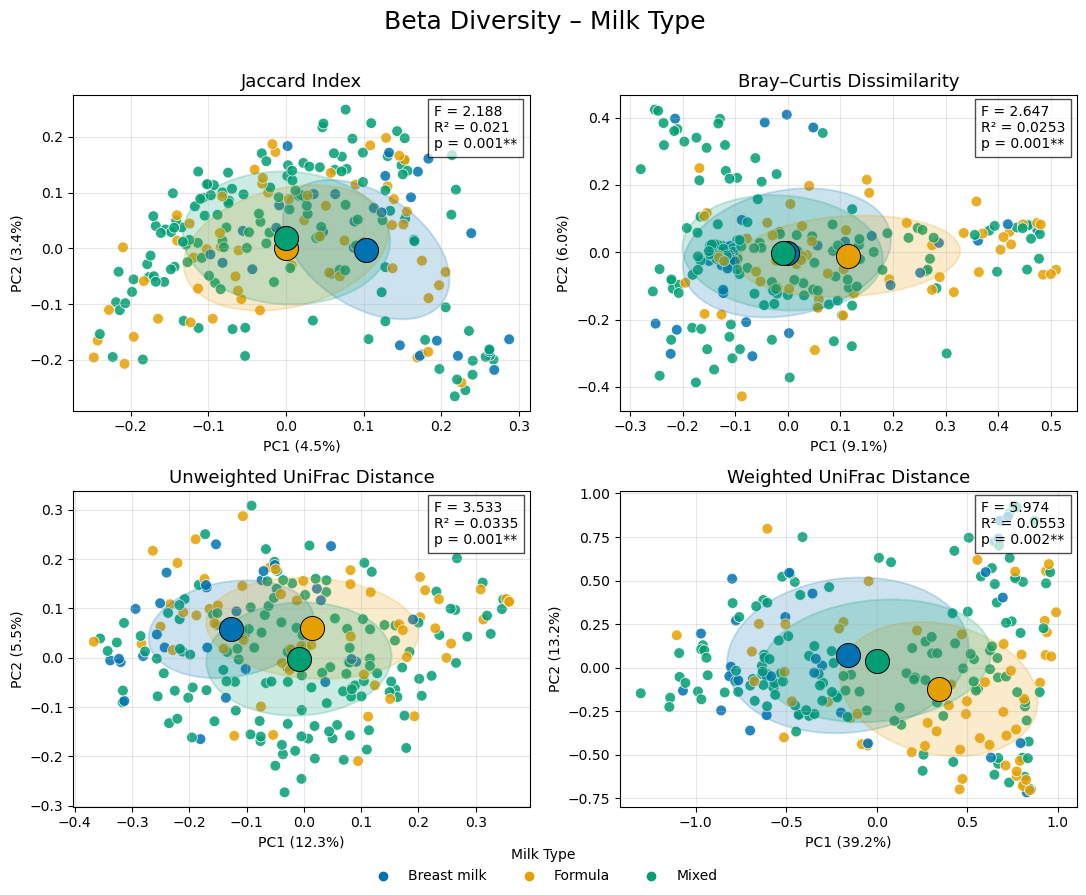

/tmp/ipykernel_10680/1252977218.py:47: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df[column] = df[column].replace(rename_dict).astype("category")
/tmp/ipykernel_10680/3361223254.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, sub in df.groupby(column):
/tmp/ipykernel_10680/1252977218.py:47: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df[column] = df[colum

Saved figure to: ../data/processed/diversity/depth-14000_no-filter/beta/plots/diet_weaning_PCoA_with_stats.png


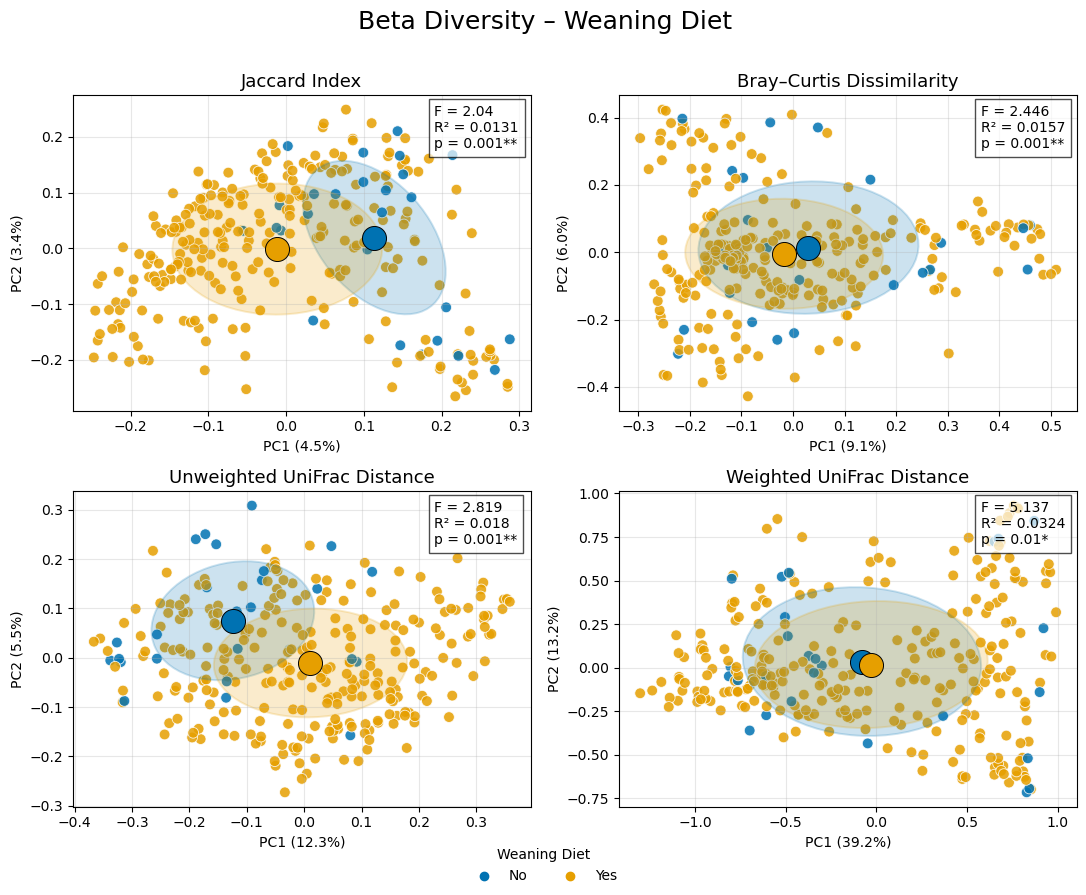

/tmp/ipykernel_10680/3361223254.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, sub in df.groupby(column):
/tmp/ipykernel_10680/3361223254.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, sub in df.groupby(column):
/tmp/ipykernel_10680/3361223254.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, sub in df.groupby(column):
/tmp/ipykernel_10680/3361223254.py:30: FutureWarning: T

Saved figure to: ../data/processed/diversity/depth-14000_no-filter/beta/plots/age_months_PCoA_with_stats.png


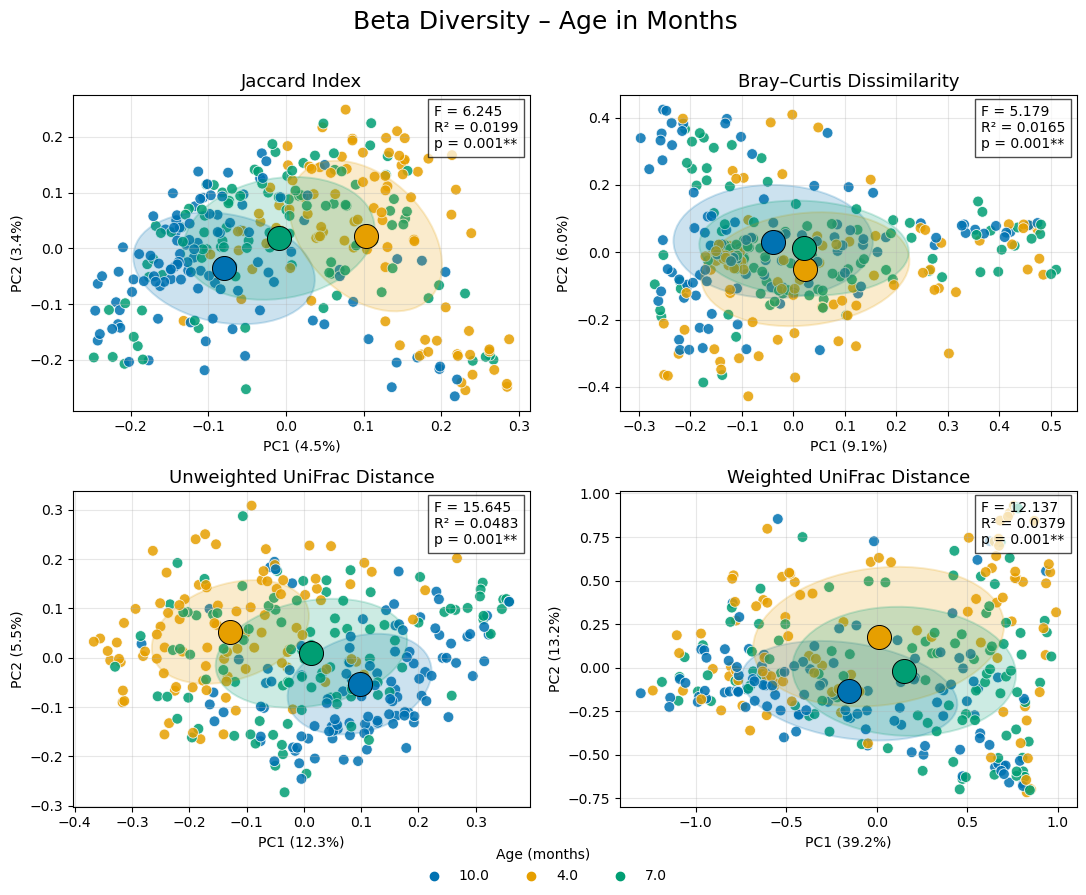

In [40]:
# Define cleaner and more descriptive labels for the beta diversity metrics
# These labels are used as titles in the PCoA subplots
metric_labels = {
    "Bray–Curtis": "Bray–Curtis Dissimilarity",
    "Jaccard": "Jaccard Index",
    "Unweighted UniFrac": "Unweighted UniFrac Distance",
    "Weighted UniFrac": "Weighted UniFrac Distance"
}

# Rename dictionary for milk type categories
# This improves readability of the plot legends
rename_milk = {
    "bd": "Breast milk",
    "fd": "Formula",
    "mixed": "Mixed"
}

# Rename dictionary for weaning categories
rename_weaning = {
    "yes": "Yes",
    "no": "No"
}

# age_months is numeric and does not require renaming


# Directory where the PCoA figures will be saved
export_dir = f"{run_dir}/beta/plots"
os.makedirs(export_dir, exist_ok=True)


# Create PCoA plots for diet_milk
plot_all_metrics_for_column_with_stats(
    column="diet_milk",
    rename_dict=rename_milk,
    metric_labels=metric_labels,
    legend_title="Milk Type",
    legend_position="lower center",
    figure_title="Beta Diversity – Milk Type",
    centroid_marker="o",
    export_dir=export_dir
)


# Create PCoA plots for diet_weaning
plot_all_metrics_for_column_with_stats(
    column="diet_weaning",
    rename_dict=rename_weaning,
    metric_labels=metric_labels,
    legend_title="Weaning Diet",
    legend_position="lower center",
    figure_title="Beta Diversity – Weaning Diet",
    centroid_marker="o",
    export_dir=export_dir
)


# Create PCoA plots for age_months
plot_all_metrics_for_column_with_stats(
    column="age_months",
    rename_dict=None,   # numeric variable
    metric_labels=metric_labels,
    legend_title="Age (months)",
    legend_position="lower center",
    figure_title="Beta Diversity – Age in Months",
    centroid_marker="o",
    export_dir=export_dir
)


### 4.4 Visualizing static variables across measurement points  

In this section, we visualize metadata variables that do not change within infants, including geo_location_name, delivery_mode, and treatment_exposure. For these variables, PERMANOVA was performed separately within each age group using one sample per infant. The PCoA plots allow us to examine whether differences in beta diversity associated with these static variables are visible within each age group and to compare these patterns with the age-stratified PERMANOVA results.


/tmp/ipykernel_10680/3361223254.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, sub in df.groupby(column):
/tmp/ipykernel_10680/3361223254.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, sub in df.groupby(column):
/tmp/ipykernel_10680/3361223254.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, sub in df.groupby(column):
/tmp/ipykernel_10680/3361223254.py:30: FutureWarning: T

Saved figure to: ../data/processed/diversity/depth-14000_no-filter/beta/plots/geo_location_name_PCoA_with_stats.png


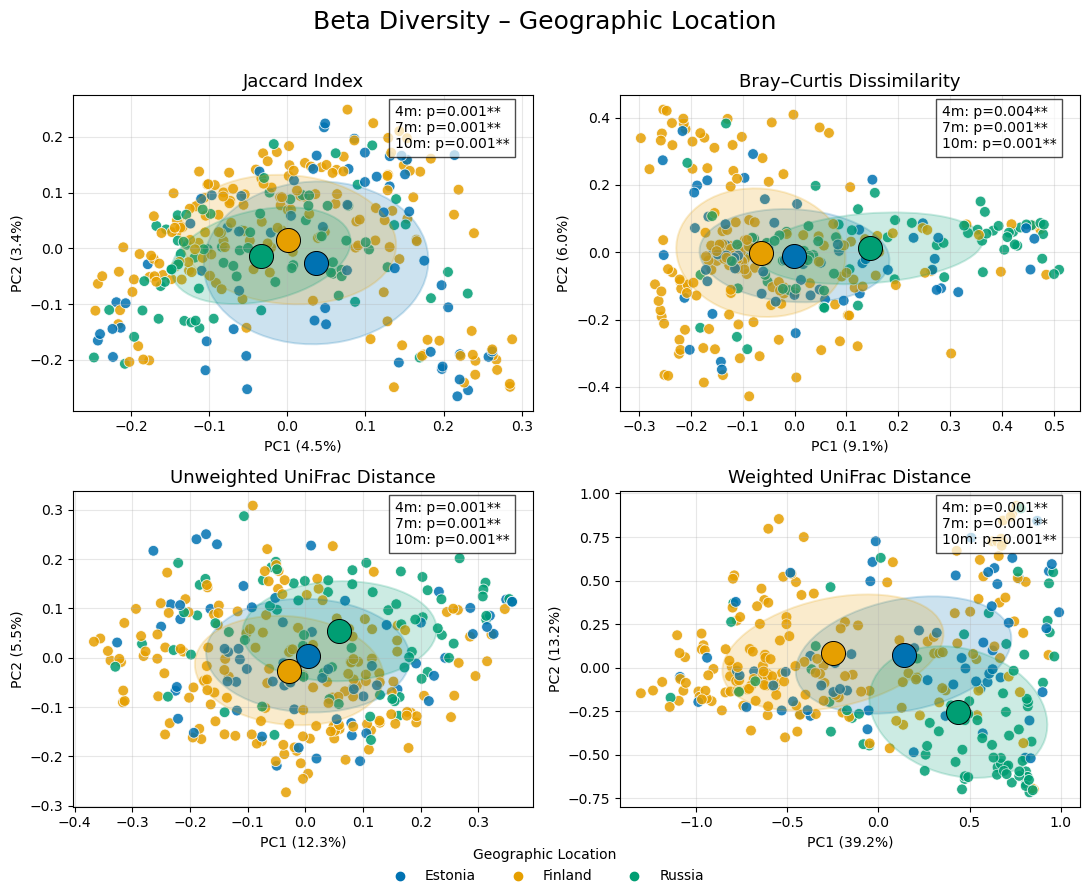

/tmp/ipykernel_10680/1252977218.py:47: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df[column] = df[column].replace(rename_dict).astype("category")
/tmp/ipykernel_10680/3361223254.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, sub in df.groupby(column):
/tmp/ipykernel_10680/1252977218.py:47: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df[column] = df[colum

Saved figure to: ../data/processed/diversity/depth-14000_no-filter/beta/plots/delivery_mode_PCoA_with_stats.png


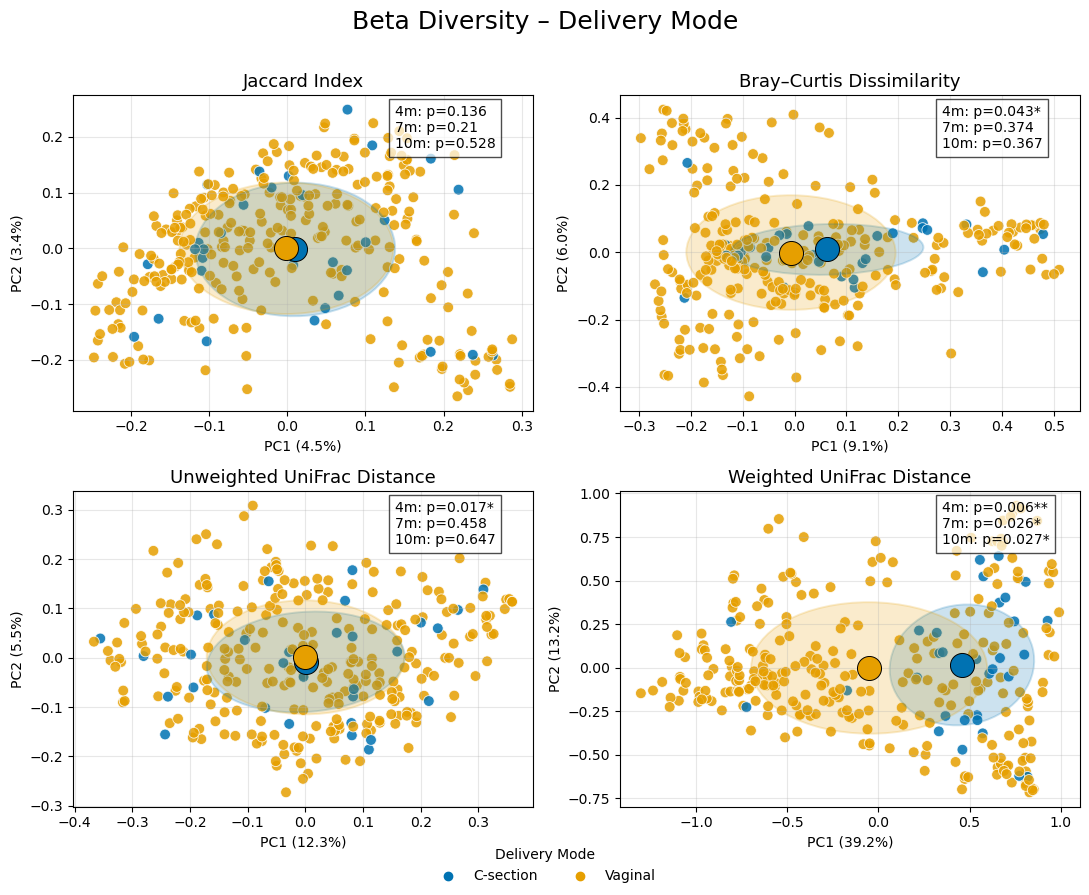

/tmp/ipykernel_10680/1252977218.py:47: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df[column] = df[column].replace(rename_dict).astype("category")
/tmp/ipykernel_10680/3361223254.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, sub in df.groupby(column):
/tmp/ipykernel_10680/1252977218.py:47: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df[column] = df[colum

Saved figure to: ../data/processed/diversity/depth-14000_no-filter/beta/plots/treatment_exposure_PCoA_with_stats.png


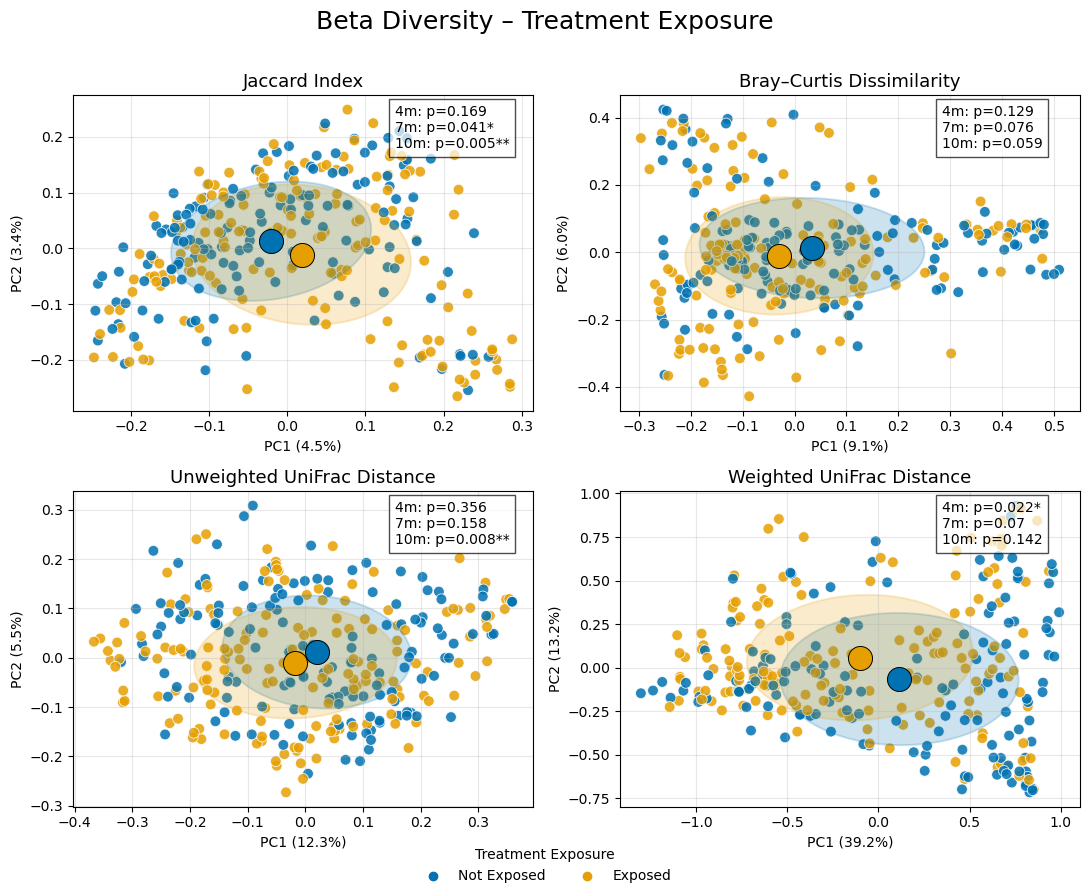

In [41]:
# Rename dictionaries for static metadata variables
# These make legend labels clearer and more readable in the plots

rename_geo = {
    "Finland": "Finland",
    "Estonia": "Estonia",
    "Russia": "Russia"
}

rename_delivery = {
    "vaginal": "Vaginal",
    "cesarean": "C-section"
}

rename_treatment = {
    "True": "Exposed",
    "False": "Not Exposed",
    True: "Exposed",
    False: "Not Exposed"
}


# Create PCoA plots for geographic location
plot_all_metrics_for_column_with_stats(
    column="geo_location_name",
    rename_dict=rename_geo,
    metric_labels=metric_labels,
    legend_title="Geographic Location",
    legend_position="lower center",
    figure_title="Beta Diversity – Geographic Location",
    centroid_marker="o",
    export_dir=export_dir,
    static=True
)


# Create PCoA plots for delivery mode
plot_all_metrics_for_column_with_stats(
    column="delivery_mode",
    rename_dict=rename_delivery,
    metric_labels=metric_labels,
    legend_title="Delivery Mode",
    legend_position="lower center",
    figure_title="Beta Diversity – Delivery Mode",
    centroid_marker="o",
    export_dir=export_dir,
    static=True
)


# Create PCoA plots for treatment exposure
plot_all_metrics_for_column_with_stats(
    column="treatment_exposure",
    rename_dict=rename_treatment,
    metric_labels=metric_labels,
    legend_title="Treatment Exposure",
    legend_position="lower center",
    figure_title="Beta Diversity – Treatment Exposure",
    centroid_marker="o",
    export_dir=export_dir,
    static=True
)


<div style="border: 2px solid #1f77b4; padding: 10px; border-radius: 6px; background-color: #eaf3fb;">
<b>Answers to the research questions</b>

<ul>
<li>
<b>How does alpha diversity (richness, Shannon diversity) vary with age and across metadata groups?</b><br>
We explored overall alpha diversity patterns and performed initial group-level comparisons to gain a first impression of how richness and Shannon diversity vary with age, feeding pattern, delivery mode, treatment exposure, and geographic location. However, these exploratory tests do not account for repeated measurements from the same infants and therefore cannot be used for final inference. A proper statistical analysis of alpha diversity using longitudinal methods, such as linear mixed-effects models, will be performed in the next notebook.
</li>

<br>

<li>
<b>How does beta diversity (community composition) vary with age and across metadata groups, and which factors explain the largest share of variation?</b><br><br>

Beta diversity analyses indicate that microbial community composition changes over infancy and is influenced by both time-varying and time-invariant metadata variables.

Among variables that change within infants over time, age in months is associated with the largest proportion of explained variation across all beta diversity metrics, suggesting consistent shifts in community composition as infants grow older. Diet-related variables also show associations with beta diversity. Differences in milk type are linked to changes in community structure, and weaning status captures additional variation as infants transition toward more diverse diets. Overall, age and diet-related variables are associated with differences in beta diversity across samples in this dataset.

For variables that remain constant within infants, including geographic location, delivery mode, and treatment exposure, age-stratified PERMANOVA analyses provide further insight. Geographic location shows the most consistent association with beta diversity across all ages, with stronger effects observed for phylogenetically weighted metrics. Delivery mode shows weaker and less consistent associations, with some evidence of effects at earlier ages and for specific distance metrics. Treatment exposure displays modest and age-dependent associations that are generally smaller and less stable than those observed for geographic location.

Overall, differences in beta diversity are associated with age, diet, and geographic location, whereas delivery mode and treatment exposure show weaker and less consistent associations.

</li>
</ul>
</div>


### Optional Cleanup: Remove an Old Run Directory

This block is optional. If you want to re-run the pipeline from scratch with the same parameters, you can delete the existing run directory first. The code is commented out to avoid accidentally removing data.

In [42]:
# ======================================================
# DELETE RUN DIRECTORY 
# ======================================================
# Uncomment the lines below to delete the entire run_dir.
# This is useful if you want to re-run the pipeline cleanly
# with the same sampling depth or filters.
# ======================================================

# folder_to_delete = run_dir
# # #folder_to_delete = f"{diversity_data_dir}/depth-14000_no-filter"

# if os.path.exists(folder_to_delete):
#     print("Fast deletion with verbose output...\n")
#     !rm -rfv {folder_to_delete}
#     print("Directory deleted.")
# else:
#     print("Unsafe path — aborting.")

# References

QIIME 2 Documentation. (2024). core-metrics-phylogenetic: Core diversity metrics (phylogenetic and non-phylogenetic). https://docs.qiime2.org/2024.10/plugins/available/diversity/core-metrics-phylogenetic/

National Cancer Institute, Center for Cancer Research. QIIME 2: Lesson 5 — Microbial Diversity and Core Metrics. https://bioinformatics.ccr.cancer.gov/docs/qiime2/Lesson5/

Oksanen, J., Blanchet, F. G., Friendly, M., Kindt, R., Legendre, P., McGlinn, D., Minchin, P. R., O’Hara, R. B., Simpson, G. L., Solymos, P., Stevens, M. H. H., Szoecs, E., & Wagner, H. (2025). adonis2: Permutational Multivariate Analysis of Variance Using Distance Matrices. In *vegan: Community Ecology Package*. CRAN. https://search.r-project.org/CRAN/refmans/vegan/html/adonis.html 
